<a href="https://colab.research.google.com/github/Sumit157/Binary-tree/blob/main/rPPG_Deepfake_Detector_v2_fixed_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫀 rPPG-Based Deepfake Detector  v2
### Biological signal analysis — training-free · CPU-only · interpretable
**By Gauraav Kate & Atharav Shelar, MIT WPU**

> **v2 fix:** Uses MediaPipe Tasks API (compatible with mediapipe ≥ 0.10)

**Novel features beyond the paper:**
- 🆕 **Phase Coherence (C)** — cross-ROI phase stability via Hilbert transform
- 🆕 **Harmonic Ratio (H)** — checks 2f and 3f cardiac harmonics


In [ ]:
!pip install -q mediapipe opencv-python-headless scipy matplotlib numpy
print("✓ Packages installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.2 MB/s eta 0:00:00
✓ Packages installed


In [ ]:
import urllib.request, os

MODEL_PATH = "face_landmarker.task"
MODEL_URL  = (
    "https://storage.googleapis.com/mediapipe-models/"
    "face_landmarker/face_landmarker/float16/1/face_landmarker.task"
)

if not os.path.exists(MODEL_PATH):
    print("Downloading MediaPipe face landmarker model (~6 MB)...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print(f"✓ Model saved → {MODEL_PATH}")
else:
    print(f"✓ Model already present → {MODEL_PATH}")


✓ Model saved → face_landmarker.task


In [ ]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks            import python  as mp_python
from mediapipe.tasks.python     import vision  as mp_vision
from scipy.signal import butter, filtfilt, hilbert
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, sys
warnings.filterwarnings('ignore')

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

CFG = {
    'f_low'         : 0.7,    # Hz  (42 BPM)
    'f_high'        : 4.0,    # Hz  (240 BPM)
    'filter_order'  : 3,
    'hr_min'        : 42,
    'hr_max'        : 180,
    'thresh_energy' : 3.0,
    'thresh_dom'    : 0.03,
    'thresh_phase'  : 0.55,   # novel
    'thresh_harm'   : 0.03,   # novel
    'max_frames'    : 900,
    'min_frames'    : 60,
    'model_path'    : 'face_landmarker.task',
    'target_w'      : 480,    # resize every frame to this width
    'thresh_roi_corr': 0.60,  # cross-ROI Pearson r  (real > 0.60)
    'thresh_amp_cv'  : 0.45,  # amplitude CoV across ROIs (real < 0.45)
}
print("✓ Imports + config OK")
print(f"  MediaPipe version : {mp.__version__}")


✓ Imports + config OK
  MediaPipe version : 0.10.33


In [ ]:
class rPPGPipeline:

    def __init__(self, cfg=CFG):
        self.cfg         = cfg
        self._landmarker = None

    # ── lazy-init landmarker (Tasks API) ──────────────────────────────────
    def _get_landmarker(self):
        if self._landmarker is None:
            base_opts = mp_python.BaseOptions(
                model_asset_path=self.cfg['model_path']
            )
            opts = mp_vision.FaceLandmarkerOptions(
                base_options=base_opts,
                num_faces=1,
                min_face_detection_confidence=0.1,   # relaxed for varied videos
                min_face_presence_confidence=0.1,
                min_tracking_confidence=0.1,
                output_face_blendshapes=False,
                output_facial_transformation_matrixes=False,
            )
            self._landmarker = mp_vision.FaceLandmarker.create_from_options(opts)
            print("  ✓ FaceLandmarker initialised")
        return self._landmarker

    # ── Stage 1: frame extraction ─────────────────────────────────────────
    @staticmethod
    def _normalise_frame(frame, target_w=480):
        """Resize to target_w preserving aspect ratio. No rotation — portrait
        videos are fed as-is; rotating sideways breaks face detection."""
        h, w = frame.shape[:2]
        scale = target_w / w
        return cv2.resize(frame, (target_w, int(h * scale)),
                          interpolation=cv2.INTER_AREA)

    @staticmethod
    def _enhance_frame(frame):
        """CLAHE on dark frames so MediaPipe can find the face."""
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if gray.mean() < 90:
            lab   = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
            clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
            lab[:, :, 0] = clahe.apply(lab[:, :, 0])
            frame = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
        return frame

    def extract_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError(f"Cannot open: {video_path}")
        fps   = cap.get(cv2.CAP_PROP_FPS) or 30.0
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        step  = max(1, total // self.cfg['max_frames'])
        tw    = self.cfg.get('target_w', 480)
        frames, idx = [], 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if idx % step == 0:
                frame = self._normalise_frame(frame, tw)
                frame = self._enhance_frame(frame)
                frames.append(frame)
            idx += 1
        cap.release()
        h, w = frames[0].shape[:2] if frames else (0, 0)
        print(f"  {total} total frames @ {fps:.1f} fps  →  sampled {len(frames)}  ({w}×{h})")
        return frames, fps

    # ── Stage 2: ROI bounding boxes ───────────────────────────────────────
    def _get_rois(self, landmarks, h, w):
        pts = [(int(lm.x * w), int(lm.y * h)) for lm in landmarks]
        xs  = [p[0] for p in pts]; ys = [p[1] for p in pts]
        x0, x1 = min(xs), max(xs); y0, y1 = min(ys), max(ys)
        fw, fh  = x1 - x0, y1 - y0
        forehead = (x0 + fw//4,        y0 + int(fh*0.04),
                    x0 + 3*fw//4,      y0 + int(fh*0.22))
        l_cheek  = (x0 + int(fw*0.08), y0 + int(fh*0.42),
                    x0 + int(fw*0.38), y0 + int(fh*0.68))
        r_cheek  = (x0 + int(fw*0.62), y0 + int(fh*0.42),
                    x0 + int(fw*0.92), y0 + int(fh*0.68))
        return forehead, l_cheek, r_cheek

    def _haar_rois(self, frame):
        """Fallback: Haar cascade → derive forehead/cheek ROIs from bbox."""
        if not hasattr(self, '_haar'):
            self._haar = cv2.CascadeClassifier(
                cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dets = self._haar.detectMultiScale(
            gray, scaleFactor=1.05, minNeighbors=2, minSize=(30, 30))
        if len(dets) == 0:
            return None
        x0, y0, fw, fh = max(dets, key=lambda d: d[2]*d[3])  # largest face
        x1, y1 = x0+fw, y0+fh
        forehead = (x0 + fw//4,        y0 + int(fh*0.04),
                    x0 + 3*fw//4,      y0 + int(fh*0.22))
        l_cheek  = (x0 + int(fw*0.08), y0 + int(fh*0.42),
                    x0 + int(fw*0.38), y0 + int(fh*0.68))
        r_cheek  = (x0 + int(fw*0.62), y0 + int(fh*0.42),
                    x0 + int(fw*0.92), y0 + int(fh*0.68))
        return forehead, l_cheek, r_cheek

    def _mean_green(self, frame, roi):
        xa, ya, xb, yb = roi
        xa = max(0, xa); ya = max(0, ya)
        xb = min(frame.shape[1], xb); yb = min(frame.shape[0], yb)
        if xb <= xa or yb <= ya:
            return np.nan
        return float(np.mean(frame[ya:yb, xa:xb, 1]))

    # ── Stage 3: raw per-ROI signals ──────────────────────────────────────
    def extract_signals(self, frames):
        detector    = self._get_landmarker()
        g_fore, g_left, g_right, hits = [], [], [], 0
        haar_hits   = 0

        for frame in frames:
            rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result = detector.detect(mp_img)

            if result.face_landmarks:
                landmarks = result.face_landmarks[0]
                h, w = frame.shape[:2]
                fore, lc, rc = self._get_rois(landmarks, h, w)
                hits += 1
            else:
                # ── Haar cascade fallback ──────────────────────────────
                rois = self._haar_rois(frame)
                if rois is not None:
                    fore, lc, rc = rois
                    haar_hits += 1
                else:
                    g_fore.append(np.nan)
                    g_left.append(np.nan)
                    g_right.append(np.nan)
                    continue

            g_fore.append(self._mean_green(frame, fore))
            g_left.append(self._mean_green(frame, lc))
            g_right.append(self._mean_green(frame, rc))

        total_hits = hits + haar_hits
        cov = total_hits / max(len(frames), 1)
        print(f"  Face detected in {cov*100:.1f}% of frames "
              f"({hits} MediaPipe + {haar_hits} Haar / {len(frames)})")

        if cov < 0.05:
            raise ValueError(
                f"Face coverage only {cov*100:.1f}%. "
                "Try a clearer, well-lit frontal video."
            )
        if cov < 0.25:
            print(f"  ⚠️  Low coverage ({cov*100:.1f}%) — proceeding, gaps interpolated")

        def fix_nans(a):
            a = np.array(a, dtype=float)
            nans = np.isnan(a)
            if nans.all(): return a
            idx = np.arange(len(a))
            a[nans] = np.interp(idx[nans], idx[~nans], a[~nans])
            return a

        return fix_nans(g_fore), fix_nans(g_left), fix_nans(g_right)

    # ── Stage 4: fusion + Butterworth bandpass ────────────────────────────
    def filter_signals(self, g_fore, g_left, g_right, fps):
        fused = (g_fore + g_left + g_right) / 3.0
        nyq   = fps / 2.0
        lo    = np.clip(self.cfg['f_low']  / nyq, 1e-4, 0.999)
        hi    = np.clip(self.cfg['f_high'] / nyq, 1e-4, 0.999)
        if lo >= hi:
            raise ValueError(
                f"Filter range invalid (lo={lo:.3f} >= hi={hi:.3f}). "
                f"fps={fps:.1f} may be too low."
            )
        b, a = butter(self.cfg['filter_order'], [lo, hi], btype='band')
        return (fused,
                filtfilt(b, a, fused),
                filtfilt(b, a, g_fore),
                filtfilt(b, a, g_left),
                filtfilt(b, a, g_right))

    # ── Stage 5: FFT + features ────────────────────────────────────────────
    def extract_features(self, filt_fused, filt_fore, filt_left, filt_right, fps):
        N     = len(filt_fused)
        freqs = np.fft.rfftfreq(N, d=1.0/fps)
        spec  = np.abs(np.fft.rfft(filt_fused))

        mask  = (freqs >= self.cfg['f_low']) & (freqs <= self.cfg['f_high'])
        if not np.any(mask):
            raise ValueError("No FFT bins in cardiac band. Video too short?")

        c_freq, c_spec = freqs[mask], spec[mask]
        pk     = np.argmax(c_spec)
        f_peak = c_freq[pk]
        hr     = f_peak * 60.0
        e_peak = c_spec[pk]
        dom    = e_peak / (np.sum(c_spec) + 1e-10)

        # Harmonic ratio
        def energy_near(f_target, tol=0.2):
            idxs = np.where(np.abs(freqs - f_target) < tol)[0]
            return float(np.max(spec[idxs])) if len(idxs) else 0.0
        harm_ratio = (energy_near(2*f_peak) + energy_near(3*f_peak)) / (e_peak + 1e-10)

        # Phase coherence (novel)
        def phase(s):
            return np.unwrap(np.angle(hilbert(s)))
        pf, pl, pr = phase(filt_fore), phase(filt_left), phase(filt_right)
        stab      = np.mean([np.std(pf-pl), np.std(pf-pr), np.std(pl-pr)])
        coherence = float(np.exp(-stab / (2*np.pi)))

        # Cross-ROI Pearson correlation (NEW — key deepfake tell)
        from scipy.stats import pearsonr
        r_fl, _ = pearsonr(filt_fore, filt_left)
        r_fr, _ = pearsonr(filt_fore, filt_right)
        r_lr, _ = pearsonr(filt_left, filt_right)
        roi_corr = float(np.mean([r_fl, r_fr, r_lr]))

        # Amplitude CoV across ROIs (NEW)
        def peak_amp(sig):
            sp = np.abs(np.fft.rfft(sig))
            return float(sp[mask][np.argmax(sp[mask])])
        amps   = [peak_amp(filt_fore), peak_amp(filt_left), peak_amp(filt_right)]
        amp_cv = float(np.std(amps) / (np.mean(amps) + 1e-10))

        return dict(
            hr=hr, f_peak=f_peak, e_peak=e_peak,
            dominance=dom, harmonic_ratio=harm_ratio, phase_coherence=coherence,
            roi_corr=roi_corr, amp_cv=amp_cv,
            freqs=freqs, spectrum=spec,
            cardiac_freqs=c_freq, cardiac_spectrum=c_spec,
            phase_fore=pf, phase_left=pl, phase_right=pr,
        )

    # ── Stage 6: rule-based classifier ────────────────────────────────────
    def classify(self, feat):
        reasons, verdict, c = [], 'REAL', self.cfg

        if not (c['hr_min'] <= feat['hr'] <= c['hr_max']):
            verdict = 'FAKE'
            reasons.append(f"HR={feat['hr']:.1f} BPM outside [{c['hr_min']}–{c['hr_max']}]")
        if feat['e_peak'] < c['thresh_energy']:
            verdict = 'FAKE'
            reasons.append(f"Weak signal: Epeak={feat['e_peak']:.3f} < {c['thresh_energy']}")
        if feat['dominance'] < c['thresh_dom']:
            verdict = 'FAKE'
            reasons.append(f"No dominant peak: D={feat['dominance']:.4f} < {c['thresh_dom']}")
        if feat['phase_coherence'] < c['thresh_phase']:
            verdict = 'FAKE'
            reasons.append(f"Low phase coherence: C={feat['phase_coherence']:.3f} < {c['thresh_phase']}")
        if feat['harmonic_ratio'] < c['thresh_harm']:
            verdict = 'FAKE'
            reasons.append(f"No harmonics: H={feat['harmonic_ratio']:.4f} < {c['thresh_harm']}")
        if feat['roi_corr'] < c['thresh_roi_corr']:
            verdict = 'FAKE'
            reasons.append(
                f"Spatially incoherent ROIs: corr={feat['roi_corr']:.3f} < {c['thresh_roi_corr']} "
                "(face regions have no shared heartbeat signal)"
            )
        if feat['amp_cv'] > c['thresh_amp_cv']:
            verdict = 'FAKE'
            reasons.append(
                f"Inconsistent ROI amplitudes: CV={feat['amp_cv']:.3f} > {c['thresh_amp_cv']} "
                "(real blood flow scales proportionally across face)"
            )
        if not reasons:
            reasons.append("All physiological checks passed ✓")

        return verdict, reasons

    # ── Full pipeline ──────────────────────────────────────────────────────
    def run(self, video_path):
        name = os.path.basename(video_path)
        print(f"\n{'='*55}\n  rPPG Detector — {name}\n{'='*55}")
        print("\n[1/5] Extracting frames...")
        frames, fps = self.extract_frames(video_path)
        if len(frames) < self.cfg['min_frames']:
            raise ValueError(f"Only {len(frames)} frames — need ≥ {self.cfg['min_frames']}")
        print("\n[2/5] Detecting face + ROI signals...")
        g_fore, g_left, g_right = self.extract_signals(frames)
        print("\n[3/5] Butterworth bandpass filter...")
        raw, filt, ff, fl, fr = self.filter_signals(g_fore, g_left, g_right, fps)
        print("\n[4/5] FFT + feature extraction...")
        feat = self.extract_features(filt, ff, fl, fr, fps)
        print("\n[5/5] Classifying...")
        verdict, reasons = self.classify(feat)
        self._print_result(verdict, reasons, feat)
        return dict(verdict=verdict, reasons=reasons, features=feat,
                    signals=dict(raw=raw, filt=filt, ff=ff, fl=fl, fr=fr,
                                 fps=fps, g_fore=g_fore))

    # ── Synthetic test ─────────────────────────────────────────────────────
    def run_synthetic(self, fps=30.0, duration=20, mode='real'):
        N, t, hr = int(fps*duration), np.linspace(0, duration, int(fps*duration)), 1.0
        if mode == 'real':
            g_fore  = 128 + 5.0*np.sin(2*np.pi*hr*t)        + 1.5*np.sin(4*np.pi*hr*t)        + 0.5*np.sin(6*np.pi*hr*t)        + np.random.normal(0, 0.4, N)
            g_left  = 128 + 4.8*np.sin(2*np.pi*hr*t + 0.10) + 1.4*np.sin(4*np.pi*hr*t + 0.10) + 0.4*np.sin(6*np.pi*hr*t + 0.10) + np.random.normal(0, 0.4, N)
            g_right = 128 + 5.1*np.sin(2*np.pi*hr*t + 0.12) + 1.6*np.sin(4*np.pi*hr*t + 0.12) + 0.5*np.sin(6*np.pi*hr*t + 0.12) + np.random.normal(0, 0.4, N)
        else:
            g_fore  = 128 + np.random.normal(0, 2.0, N)
            g_left  = 128 + np.random.normal(0, 2.0, N)
            g_right = 128 + np.random.normal(0, 2.0, N)

        raw, filt, ff, fl, fr = self.filter_signals(g_fore, g_left, g_right, fps)
        feat = self.extract_features(filt, ff, fl, fr, fps)
        verdict, reasons = self.classify(feat)
        print(f"\nSynthetic [{mode.upper()}]")
        self._print_result(verdict, reasons, feat)
        return dict(verdict=verdict, reasons=reasons, features=feat,
                    signals=dict(raw=raw, filt=filt, ff=ff, fl=fl, fr=fr,
                                 fps=fps, g_fore=g_fore))

    def _print_result(self, verdict, reasons, feat):
        icon = "🟢" if verdict == "REAL" else "🔴"
        print(f"\n{'='*55}")
        print(f"  VERDICT: {icon} {verdict}")
        print(f"{'='*55}")
        print(f"  Heart Rate       : {feat['hr']:.1f} BPM")
        print(f"  Peak Energy      : {feat['e_peak']:.3f}")
        print(f"  Dominance (D)    : {feat['dominance']:.4f}  (thresh {CFG['thresh_dom']})")
        print(f"  Phase Coh. (C)   : {feat['phase_coherence']:.3f}  (thresh {CFG['thresh_phase']})  ← novel")
        print(f"  Harmonic (H)     : {feat['harmonic_ratio']:.4f}  (thresh {CFG['thresh_harm']})  ← novel")
        print(f"  ROI Corr  (R)    : {feat['roi_corr']:.3f}   (thresh {CFG['thresh_roi_corr']})  ← new")
        print(f"  Amp CoV   (A)    : {feat['amp_cv']:.3f}   (thresh {CFG['thresh_amp_cv']})  ← new")
        print(f"\n  Decision reasons:")
        for r in reasons:
            print(f"    • {r}")
        print(f"{'='*55}")

print("✓ rPPGPipeline class ready")


✓ rPPGPipeline class ready


In [ ]:
def visualize(result, title="rPPG Analysis", save_path="rppg_analysis.png"):
    feat    = result['features']
    sig     = result['signals']
    fps     = sig['fps']
    verdict = result['verdict']
    N       = len(sig['filt'])
    t       = np.linspace(0, N/fps, N)
    clr     = '#2ecc71' if verdict == 'REAL' else '#e74c3c'
    BG      = '#111111'; PANEL = '#1c1c1c'; TEXT = '#cccccc'; MUTED = '#777777'

    fig = plt.figure(figsize=(16, 13), facecolor=BG)
    gs  = gridspec.GridSpec(3, 2, figure=fig,
                            hspace=0.50, wspace=0.35,
                            top=0.93, bottom=0.05, left=0.07, right=0.97)

    def ax_style(ax, ttl):
        ax.set_facecolor(PANEL)
        ax.set_title(ttl, color=TEXT, fontsize=9.5, pad=7)
        ax.tick_params(colors=MUTED, labelsize=7.5)
        for sp in ax.spines.values(): sp.set_edgecolor('#2e2e2e')
        ax.grid(True, color='#252525', linewidth=0.5, alpha=0.9)

    # 1 — Raw fused signal
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(t, sig['raw'], color='#5dade2', lw=0.7, alpha=0.9)
    ax_style(ax1, 'Raw fused green channel')
    ax1.set_xlabel('Time (s)', color=MUTED, fontsize=8)
    ax1.set_ylabel('Green intensity', color=MUTED, fontsize=8)

    # 2 — Per-ROI filtered
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(t, sig['ff'], color='#e74c3c', lw=0.7, label='Forehead',    alpha=0.85)
    ax2.plot(t, sig['fl'], color='#f39c12', lw=0.7, label='Left cheek',  alpha=0.85)
    ax2.plot(t, sig['fr'], color='#9b59b6', lw=0.7, label='Right cheek', alpha=0.85)
    ax_style(ax2, 'Filtered per-ROI signals (0.7–4.0 Hz)')
    ax2.set_xlabel('Time (s)', color=MUTED, fontsize=8)
    ax2.legend(fontsize=7, facecolor=PANEL, labelcolor=TEXT,
               framealpha=0.8, edgecolor='#2e2e2e')

    # 3 — FFT spectrum
    ax3 = fig.add_subplot(gs[1, 0])
    freqs = feat['freqs']; spec = feat['spectrum']
    m     = (freqs >= 0.4) & (freqs <= 4.6)
    ax3.fill_between(freqs[m], spec[m], color='#5dade2', alpha=0.25)
    ax3.plot(freqs[m], spec[m], color='#5dade2', lw=0.9)
    ax3.axvspan(0.7, 4.0, alpha=0.07, color='#2ecc71')
    ax3.axvline(feat['f_peak'], color=clr, lw=1.8, ls='--',
                label=f"Peak: {feat['f_peak']:.2f} Hz ({feat['hr']:.0f} BPM)")
    for n, col in [(2, '#f39c12'), (3, '#e67e22')]:
        hf = feat['f_peak'] * n
        if hf <= 4.6:
            ax3.axvline(hf, color=col, lw=1.1, ls=':', alpha=0.75,
                        label=f'{n}f harmonic')
    ax_style(ax3, 'Frequency spectrum')
    ax3.set_xlabel('Frequency (Hz)', color=MUTED, fontsize=8)
    ax3.set_ylabel('Amplitude', color=MUTED, fontsize=8)
    ax3.legend(fontsize=7, facecolor=PANEL, labelcolor=TEXT,
               framealpha=0.8, edgecolor='#2e2e2e')

    # 4 — Feature bar chart
    ax4 = fig.add_subplot(gs[1, 1])
    names = ['Dominance\n(D)', 'Phase Coh.\n(C) ★', 'Harmonic\n(H) ★',
             'ROI Corr\n(R) ✦', 'Amp CoV\n(A) ✦']
    vals  = [feat['dominance'], feat['phase_coherence'], feat['harmonic_ratio'],
             feat['roi_corr'],  feat['amp_cv']]
    thrs  = [CFG['thresh_dom'], CFG['thresh_phase'], CFG['thresh_harm'],
             CFG['thresh_roi_corr'], CFG['thresh_amp_cv']]
    # amp_cv: lower is better, so invert pass/fail colour
    cols  = ['#2ecc71' if (v >= thr if i != 4 else v <= thr) else '#e74c3c'
             for i, (v, thr) in enumerate(zip(vals, thrs))]
    x     = np.arange(len(names))
    ax4.bar(x, vals, color=cols, alpha=0.8, width=0.5, zorder=3)
    for xi, thr in zip(x, thrs):
        ax4.plot([xi-.25, xi+.25], [thr, thr], color='#ffffff',
                 lw=1.5, ls='--', alpha=0.7, zorder=4)
    ax4.set_xticks(x); ax4.set_xticklabels(names, color=TEXT, fontsize=8)
    ax_style(ax4, 'Feature values  (white dashed = threshold)')
    ax4.set_ylabel('Value', color=MUTED, fontsize=8)
    for xi, v in enumerate(vals):
        ax4.text(xi, v + max(vals)*0.03, f'{v:.4f}',
                 ha='center', color=TEXT, fontsize=7.5)

    # 5 — Phase diff (novel)
    ax5 = fig.add_subplot(gs[2, 0])
    pf = feat['phase_fore']; pl = feat['phase_left']; pr = feat['phase_right']
    ax5.plot(t, pl-pf, color='#f39c12', lw=0.7, label='Left − Fore',  alpha=0.85)
    ax5.plot(t, pr-pf, color='#9b59b6', lw=0.7, label='Right − Fore', alpha=0.85)
    ax_style(ax5, f'Cross-ROI phase differences  C={feat["phase_coherence"]:.3f}  ← novel')
    ax5.set_xlabel('Time (s)', color=MUTED, fontsize=8)
    ax5.set_ylabel('Phase diff (rad)', color=MUTED, fontsize=8)
    ax5.legend(fontsize=7, facecolor=PANEL, labelcolor=TEXT,
               framealpha=0.8, edgecolor='#2e2e2e')

    # 6 — Verdict
    ax6 = fig.add_subplot(gs[2, 1])
    ax6.set_facecolor(PANEL); ax6.axis('off')
    for sp in ax6.spines.values(): sp.set_edgecolor('#2e2e2e')
    ax6.text(0.5, 0.88, verdict, ha='center', va='center',
             color=clr, fontsize=32, fontweight='bold', transform=ax6.transAxes)
    rows = [
        ("HR",          f"{feat['hr']:.1f} BPM"),
        ("Epeak",       f"{feat['e_peak']:.3f}"),
        ("D (dom)",     f"{feat['dominance']:.4f}"),
        ("C (phase) ★", f"{feat['phase_coherence']:.3f}"),
        ("H (harm)  ★", f"{feat['harmonic_ratio']:.4f}"),
    ]
    for i, (lbl, val) in enumerate(rows):
        y = 0.69 - i*0.12
        ax6.text(0.08, y, lbl, ha='left', color=MUTED, fontsize=8.5,
                 transform=ax6.transAxes, fontfamily='monospace')
        ax6.text(0.60, y, val, ha='left', color=TEXT,  fontsize=8.5,
                 transform=ax6.transAxes, fontfamily='monospace')
    reason_str = '\n'.join([f'• {r}' for r in result['reasons']])
    ax6.text(0.08, 0.04, reason_str, ha='left', va='bottom',
             color='#888888', fontsize=7.5, transform=ax6.transAxes,
             linespacing=1.4)

    fig.suptitle(title, color='#eeeeee', fontsize=12, y=0.97)
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()
    print(f"\n✓ Saved → {save_path}")

print("✓ visualize() ready")


✓ visualize() ready


---
## Option A — Upload your video (real or deepfake)


Select your video file:


Saving Narenda modi പുതിയ ഡാൻസ് 😂😂.mp4 to Narenda modi പുതിയ ഡാൻസ് 😂😂.mp4

  rPPG Detector — Narenda modi പുതിയ ഡാൻസ് 😂😂.mp4

[1/5] Extracting frames...
  374 total frames @ 30.0 fps  →  sampled 374  (480×853)

[2/5] Detecting face + ROI signals...
  ✓ FaceLandmarker initialised
  Face detected in 99.2% of frames (11 MediaPipe + 360 Haar / 374)

[3/5] Butterworth bandpass filter...

[4/5] FFT + feature extraction...

[5/5] Classifying...

  VERDICT: 🔴 FAKE
  Heart Rate       : 96.3 BPM
  Peak Energy      : 1207.375
  Dominance (D)    : 0.0480  (thresh 0.03)
  Phase Coh. (C)   : 0.388  (thresh 0.55)  ← novel
  Harmonic (H)     : 0.7569  (thresh 0.03)  ← novel
  ROI Corr  (R)    : 0.556   (thresh 0.6)  ← new
  Amp CoV   (A)    : 0.199   (thresh 0.45)  ← new

  Decision reasons:
    • Low phase coherence: C=0.388 < 0.55
    • Spatially incoherent ROIs: corr=0.556 < 0.6 (face regions have no shared heartbeat signal)


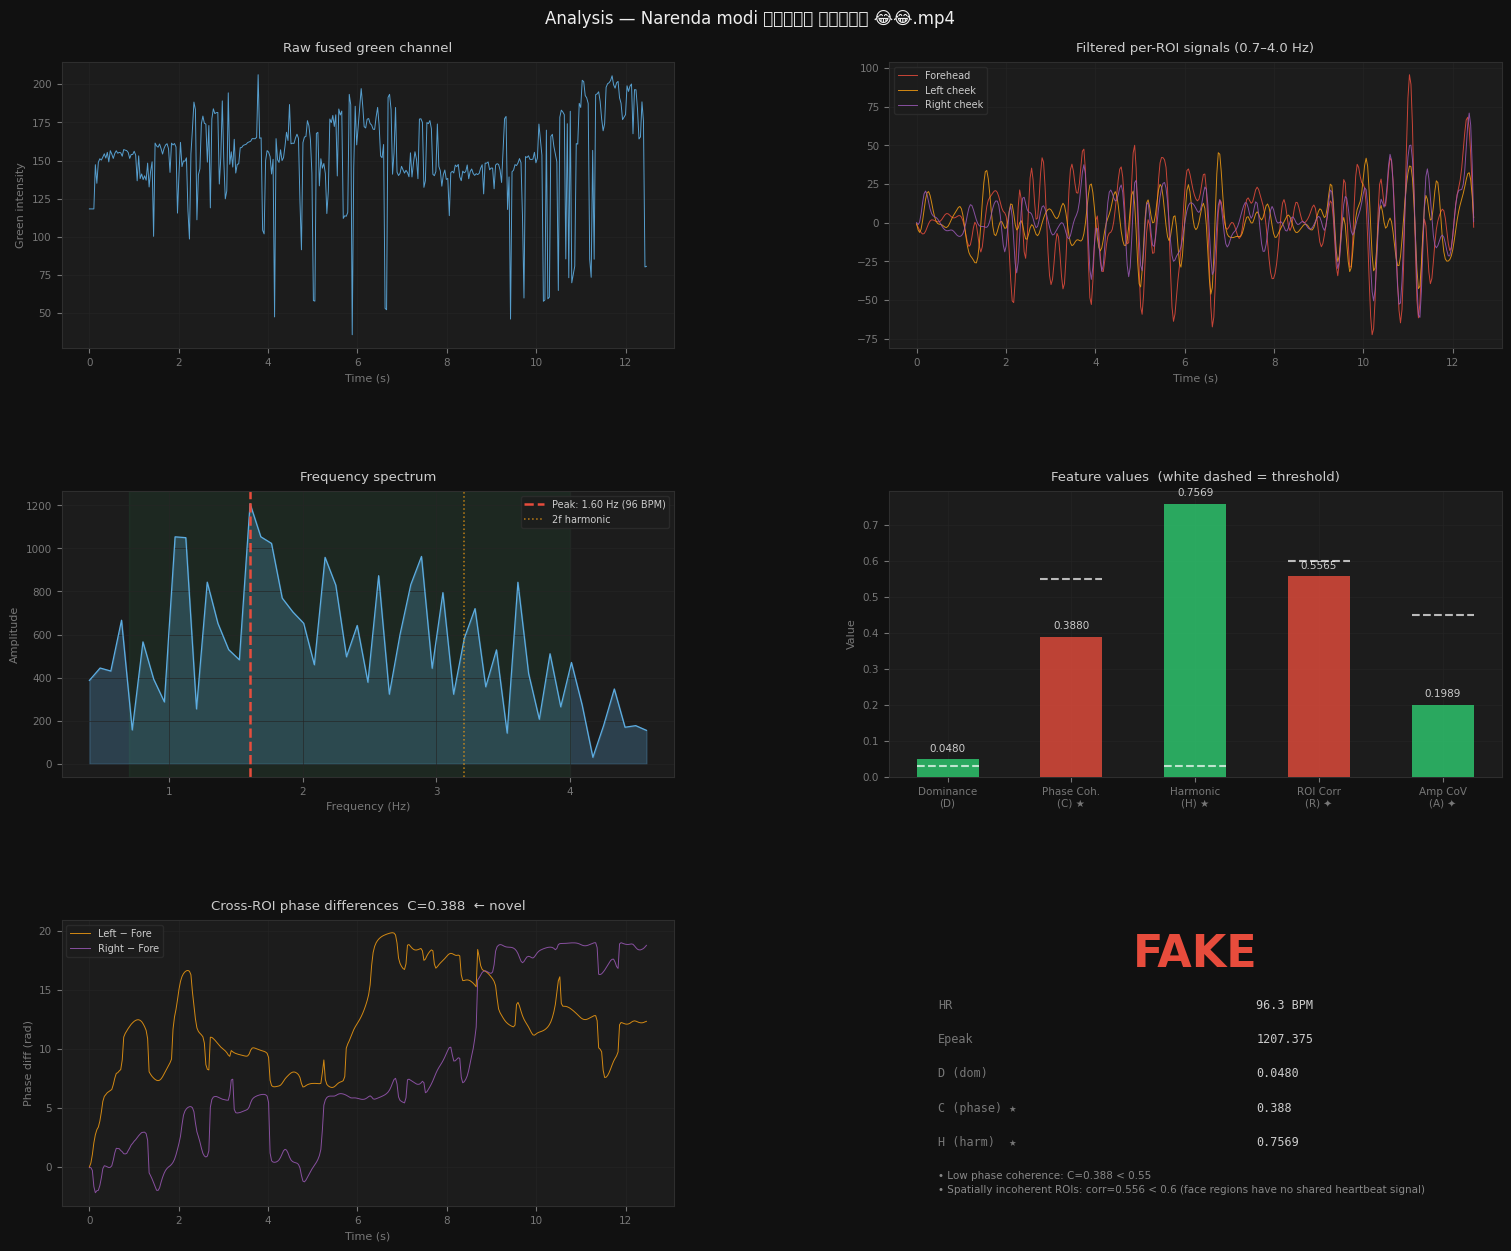


✓ Saved → analysis_upload.png


In [ ]:
if IN_COLAB:
    print("Select your video file:")
    uploaded = files.upload()
    if uploaded:
        video_path = list(uploaded.keys())[0]
        pipe   = rPPGPipeline(CFG)
        result = pipe.run(video_path)
        visualize(result,
                  title=f"Analysis — {video_path}",
                  save_path="analysis_upload.png")
    else:
        print("No file uploaded.")
else:
    VIDEO_PATH = "your_video.mp4"
    pipe   = rPPGPipeline(CFG)
    result = pipe.run(VIDEO_PATH)
    visualize(result, title=VIDEO_PATH)


---
## Option B — Synthetic Demo (no video needed)
Verify the full signal processing pipeline works without any video file.



Synthetic [REAL]

  VERDICT: 🟢 REAL
  Heart Rate       : 60.0 BPM
  Peak Energy      : 1445.965
  Dominance (D)    : 0.5406  (thresh 0.03)
  Phase Coh. (C)   : 0.991  (thresh 0.55)  ← novel
  Harmonic (H)     : 0.3971  (thresh 0.03)  ← novel
  ROI Corr  (R)    : 0.994   (thresh 0.6)  ← new
  Amp CoV   (A)    : 0.026   (thresh 0.45)  ← new

  Decision reasons:
    • All physiological checks passed ✓


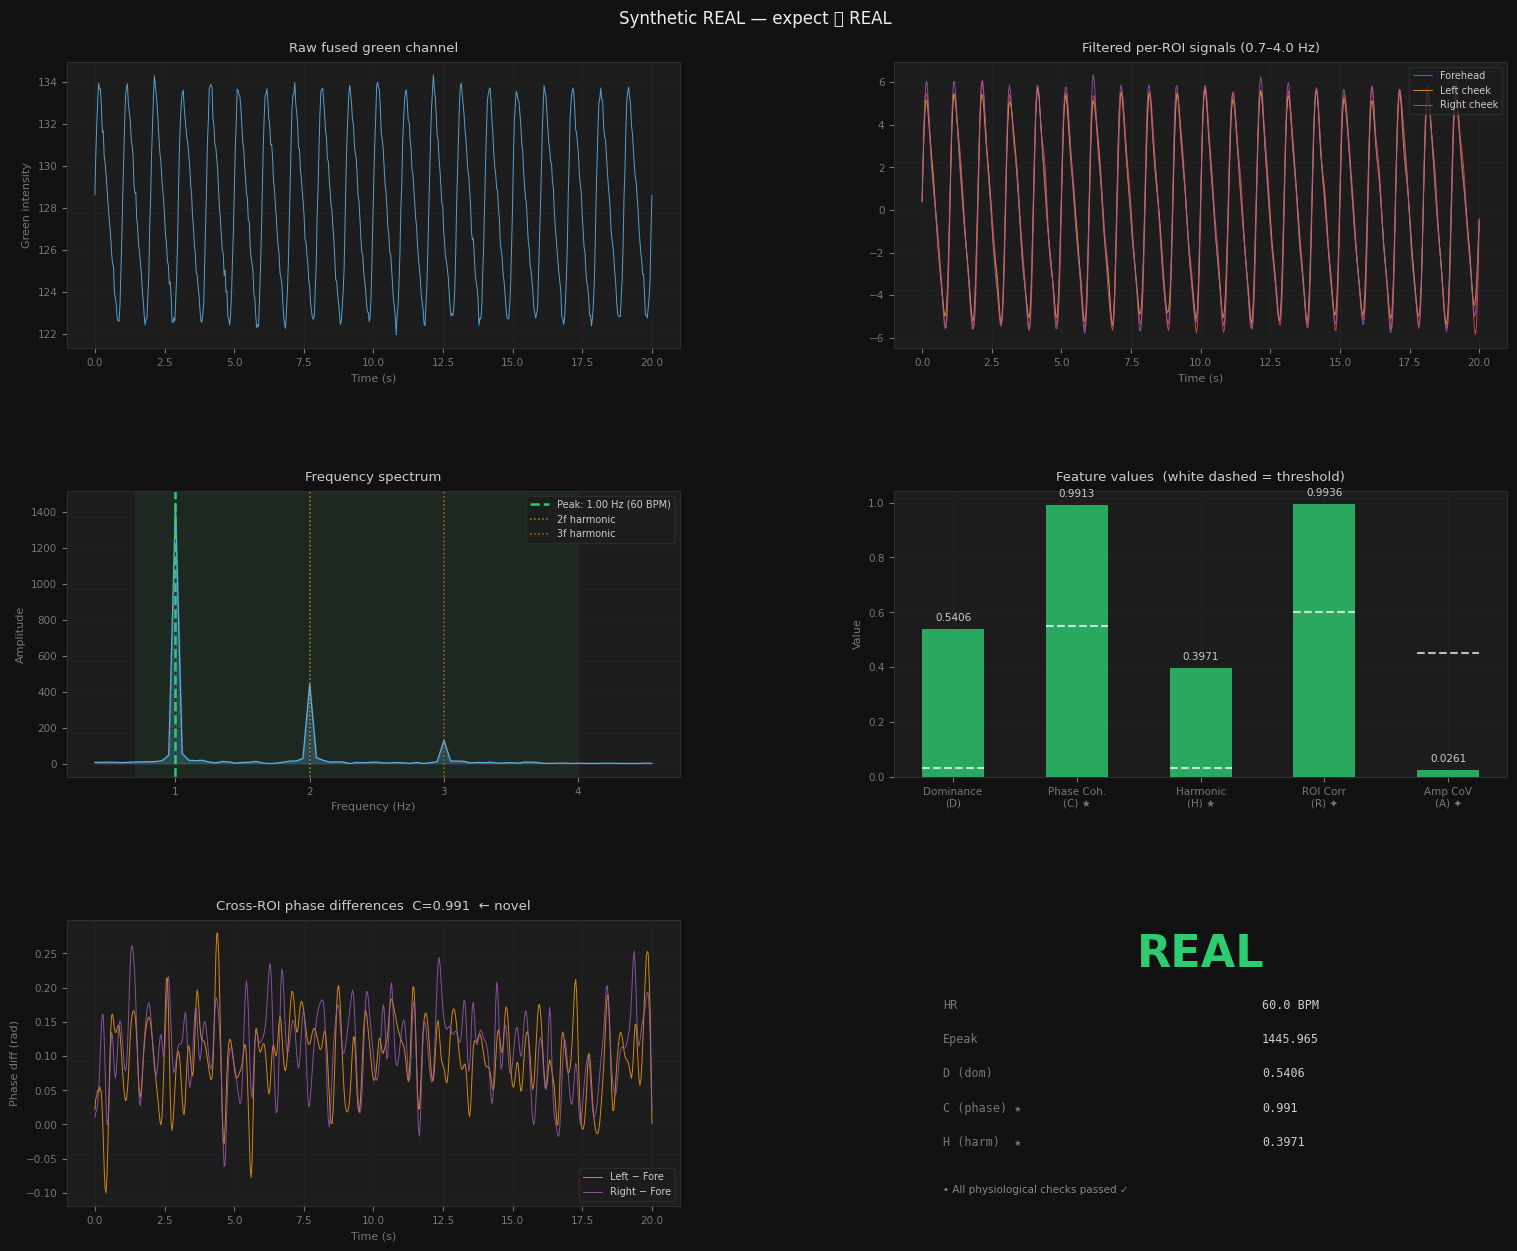


✓ Saved → synthetic_real.png


In [ ]:
pipe = rPPGPipeline(CFG)

result_real = pipe.run_synthetic(fps=30.0, duration=20, mode='real')
visualize(result_real,
          title="Synthetic REAL — expect 🟢 REAL",
          save_path="synthetic_real.png")



Synthetic [FAKE]

  VERDICT: 🔴 FAKE
  Heart Rate       : 150.0 BPM
  Peak Energy      : 67.520
  Dominance (D)    : 0.0449  (thresh 0.03)
  Phase Coh. (C)   : 0.279  (thresh 0.55)  ← novel
  Harmonic (H)     : 0.1072  (thresh 0.03)  ← novel
  ROI Corr  (R)    : 0.007   (thresh 0.6)  ← new
  Amp CoV   (A)    : 0.053   (thresh 0.45)  ← new

  Decision reasons:
    • Low phase coherence: C=0.279 < 0.55
    • Spatially incoherent ROIs: corr=0.007 < 0.6 (face regions have no shared heartbeat signal)


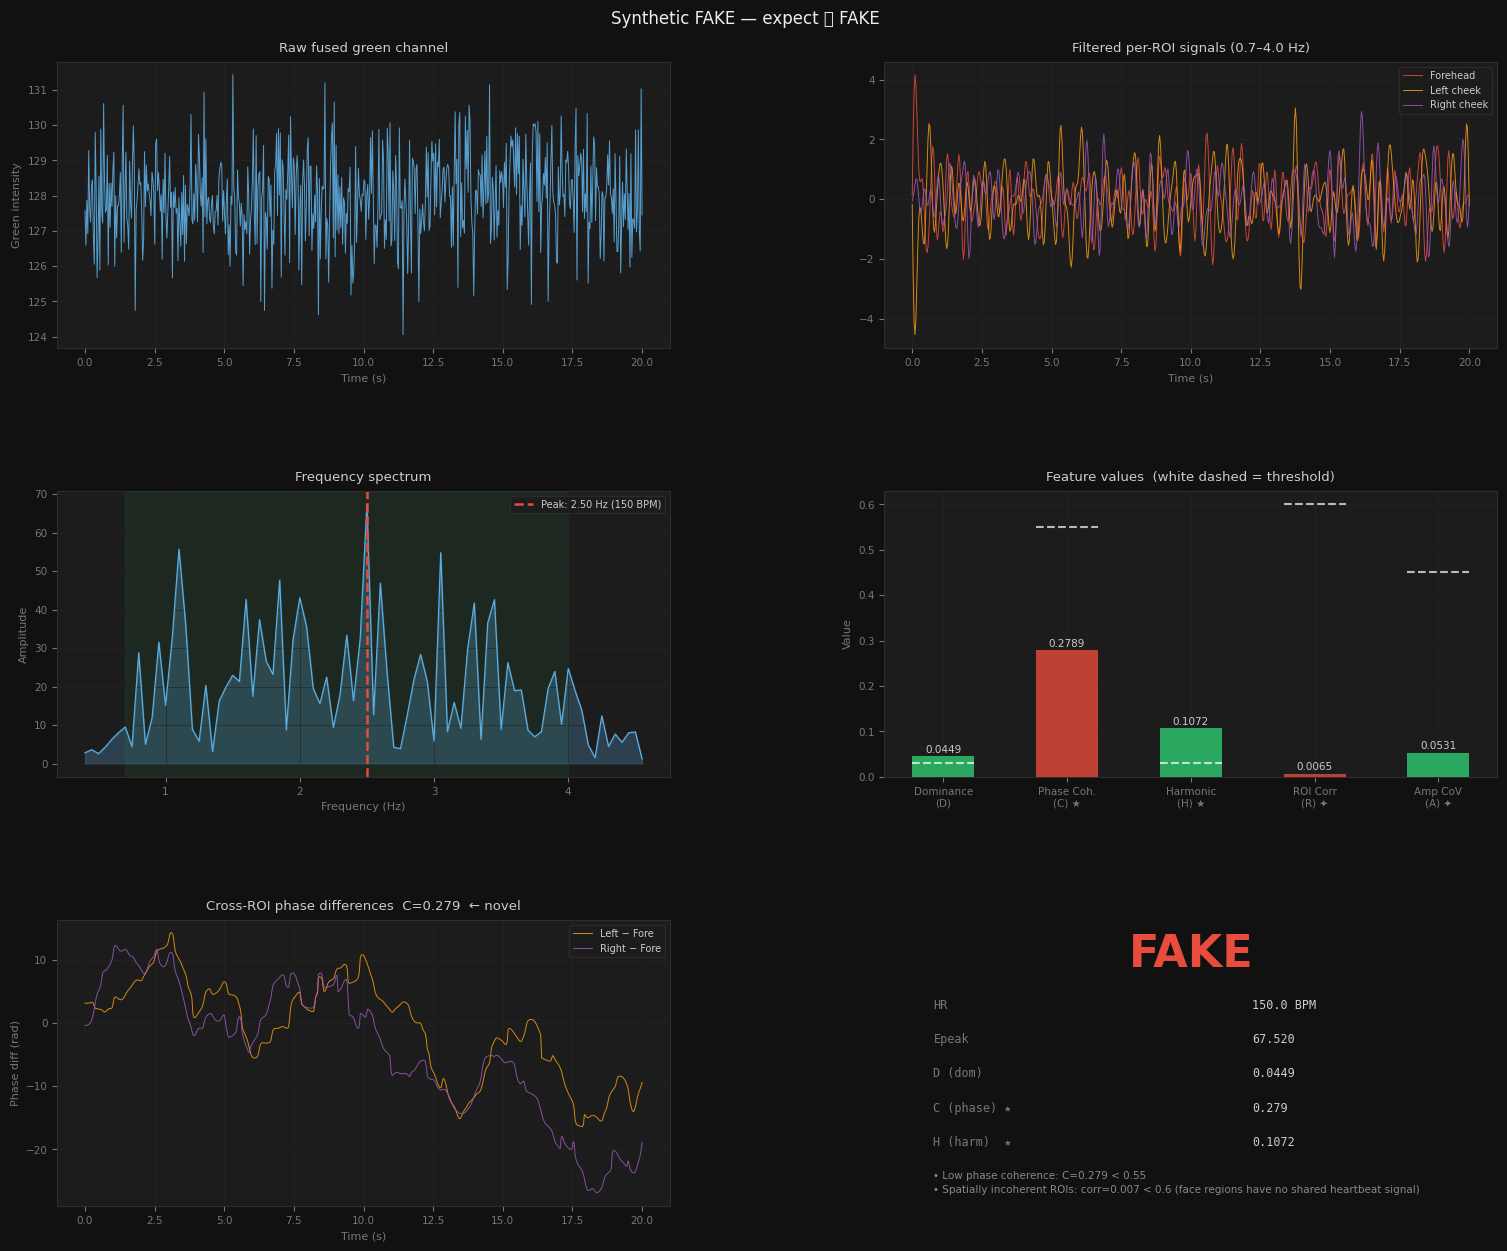


✓ Saved → synthetic_fake.png


In [ ]:
result_fake = pipe.run_synthetic(fps=30.0, duration=20, mode='fake')
visualize(result_fake,
          title="Synthetic FAKE — expect 🔴 FAKE",
          save_path="synthetic_fake.png")


---
## Threshold Tuning
Adjust if you're getting false positives / negatives on your dataset.


In [ ]:
CFG['thresh_energy'] = 3.0    # lower = less strict on signal strength
CFG['thresh_dom']    = 0.03   # lower = allows weaker dominant peaks
CFG['thresh_phase']  = 0.55   # lower = more lenient on phase coherence
CFG['thresh_harm']   = 0.03   # lower = more lenient on harmonics

print("Updated thresholds:")
for k in ['thresh_energy', 'thresh_dom', 'thresh_phase', 'thresh_harm']:
    print(f"  {k:20s}: {CFG[k]}")

# Re-classify last result with new thresholds (no reprocessing needed)
if 'result' in dir():
    pipe2 = rPPGPipeline(CFG)
    v2, r2 = pipe2.classify(result['features'])
    print(f"\nRe-classified: {'🟢' if v2=='REAL' else '🔴'} {v2}")
    for r in r2: print(f"  • {r}")


Updated thresholds:
  thresh_energy       : 3.0
  thresh_dom          : 0.03
  thresh_phase        : 0.55
  thresh_harm         : 0.03

Re-classified: 🔴 FAKE
  • Low phase coherence: C=0.388 < 0.55
  • Spatially incoherent ROIs: corr=0.556 < 0.6 (face regions have no shared heartbeat signal)
